# 24 - Noise Augmentation

**Section:** More on Data | **Prereqs:** `More on Data/Handeling_Unbalanced_Data_Exact_Replication.ipynb` | **Next:** `More on Data/CodeChallenge_UnbalancedData.ipynb`

Exact copies added nothing. Copies *with noise* do: each duplicate is now a
slightly different sample, so the model has to learn features that survive small
perturbations instead of memorising exact pixel values.

**Why it works.** It is regularisation, in the same family as dropout. Adding
noise to an input is close to penalising the model's sensitivity to that input -
a model that cannot be thrown by a noisy pixel is a model that generalised.

**Where it works:** images, audio, sensor data - anything where a small
perturbation leaves the label unchanged. It does not transfer blindly to tabular
data, where a small change in a feature can genuinely mean a different class.

**Three splits here, not two.** The data is split into train and dev *before*
any augmentation, so the dev set never contains a noisy twin of a training image;
the untouched MNIST test set is only used at the very end. Tune on dev, report on
test, once.

#Generally used for images and CNNs; also acts as **regularization**.

## Noise Augmentation for Images

Noise augmentation is a common data augmentation technique used in image processing and computer vision. It involves adding random noise to images in the training dataset. This is particularly useful for training deep learning models—such as Convolutional Neural Networks (CNNs)—to improve robustness and generalization.

## Why it’s beneficial

- **Regularization**  
  Adding noise acts like a regularizer (similar to dropout). It prevents the model from over-relying on specific pixel values or patterns. By forcing the model to learn features invariant to small perturbations, it becomes more robust to real-world variations.

- **Improved generalization**  
  Real-world images often contain noise (sensor limits, compression artifacts, environmental conditions). Training with noise-augmented data exposes the model to these variations, improving performance on unseen, noisy inputs.

- **Increased dataset size**  
  Noise augmentation effectively expands the training set by creating new variations of existing images. This is especially helpful for small datasets, providing more diverse examples and reducing overfitting.

- **Simulated real-world conditions**  
  Different noise types (e.g., **Gaussian**, **salt-and-pepper**, **speckle**) can be added to mimic real degradations, making models more resilient to such imperfections.

## Summary

By introducing controlled randomness, noise augmentation enhances model robustness, boosts generalization to unseen data, and helps mitigate overfitting—especially when working with limited image datasets.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [ ]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

In [ ]:
# Data factory with the augmentation flag.
# The order of operations is the point, and it follows the previous notebook's
# conclusion exactly:
#   1. take n samples and scale to [0,1],
#   2. SPLIT into train and dev first,
#   3. IF augmenting: copy the TRAINING half only, add uniform noise, re-scale
#      (noise pushes values above 1, so the copies must be renormalised),
#   4. concatenate the clean and noisy training data.
#
# Augmenting before splitting would let a clean image and its noisy twin land on
# opposite sides of the split, so the dev set would be scoring near-duplicates of
# training samples.
def makeDataset(n,boolDouble):

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets

  data_subset = data_tensor[:n].clone().detach().cpu().numpy() # Use clone().detach() and convert to numpy
  labels_subset = labels_tensor[:n].clone().detach().cpu().numpy() # Use clone().detach() and convert to numpy

  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_subset)

  from sklearn.model_selection import train_test_split

  train_data, dev_data , train_label, dev_label = train_test_split(data_subset, labels_subset, test_size=0.2, shuffle=True)

  if boolDouble:
    # Augment the TRAINING half only - the dev set must stay untouched.
    dataN = train_data + np.random.random_sample(train_data.shape)/2 # This is linear augmentation, we can use other forms too
    # Since after adding noise the pixel value can go above 1 so we have to re normalize it.
    dataN = scaler.fit_transform(dataN) # Re-Normalizing the data
    train_data = np.concatenate( (train_data,dataN), axis=0 )
    train_label = np.concatenate( (train_label,train_label), axis= 0)

  train_data = torch.tensor(train_data, dtype=torch.float, device='cuda')
  train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')


  dev_data = torch.tensor(dev_data, dtype=torch.float, device='cuda')
  dev_label = torch.tensor(dev_label, dtype=torch.long, device='cuda')

  train_tensor = TensorDataset(train_data, train_label)
  dev_tensor = TensorDataset(dev_data,dev_label)

  bs = 32
  data_loader = DataLoader(train_tensor, batch_size=bs, drop_last=True, shuffle=True)
  test_loader = DataLoader(dev_tensor, batch_size=dev_tensor.tensors[0].shape[0])


  return data_loader, test_loader

In [ ]:
# Build an augmented dataset of 100 samples to look at.
data_loader, test_loader = makeDataset(100,True)

In [ ]:
a = data_loader.dataset.tensors[0][3]
a_label = data_loader.dataset.tensors[1][3]

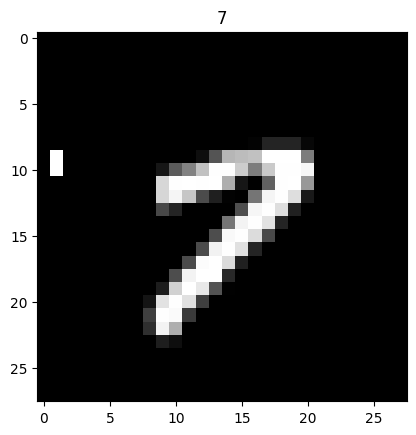

In [ ]:
# A noisy digit. It should be visibly grainy but still clearly readable -
# that is the right noise level. If you cannot read it, neither can the model,
# and the label is now wrong.
plt.imshow(a.reshape(28,28).cpu(), cmap ='gray')
plt.title(a_label.item());

In [ ]:
# The usual classifier, raw logits out.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 128)

    self.fc1 = nn.Linear(128,64)

    self.fc2 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [ ]:
# Training function taking the same (n, boolDouble) pair, so the two runs are
# identical apart from augmentation.
def train_model(n,boolDouble):

  data_loader, test_loader = makeDataset(n, boolDouble)

  classifier = model().to('cuda')

  epochs = 100
  lr = 0.0001

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  train_acc = []
  dev_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Sample Size = {data_loader.dataset.tensors[0].shape[0]} |Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      dev_acc.append( 100 * torch.mean( (Preds == Y).float()) )

  print()
  return losses, train_acc, dev_acc, classifier


In [ ]:
# The comparison: 250 clean samples vs 250 clean + 250 noisy.
losses, train_acc, dev_acc, classifier = train_model(250,False)
lossesTrue, train_accTrue, dev_accTrue, classifierTrue = train_model(250, True)

Sample Size = 200 |Epoch 0 : Loss = 2.305455207824707
Sample Size = 200 |Epoch 10 : Loss = 2.2494614124298096
Sample Size = 200 |Epoch 20 : Loss = 2.0660383701324463
Sample Size = 200 |Epoch 30 : Loss = 1.7241058349609375
Sample Size = 200 |Epoch 40 : Loss = 1.3007941246032715
Sample Size = 200 |Epoch 50 : Loss = 0.9585570096969604
Sample Size = 200 |Epoch 60 : Loss = 0.6910386085510254
Sample Size = 200 |Epoch 70 : Loss = 0.5009662508964539
Sample Size = 200 |Epoch 80 : Loss = 0.37826576828956604
Sample Size = 200 |Epoch 90 : Loss = 0.2904309332370758
Sample Size = 200 |Epoch 99 : Loss = 0.23064398765563965

Sample Size = 400 |Epoch 0 : Loss = 2.303610324859619
Sample Size = 400 |Epoch 10 : Loss = 2.1379077434539795
Sample Size = 400 |Epoch 20 : Loss = 1.6536914110183716
Sample Size = 400 |Epoch 30 : Loss = 1.09919273853302
Sample Size = 400 |Epoch 40 : Loss = 0.7072180509567261
Sample Size = 400 |Epoch 50 : Loss = 0.4664308726787567
Sample Size = 400 |Epoch 60 : Loss = 0.315633624792

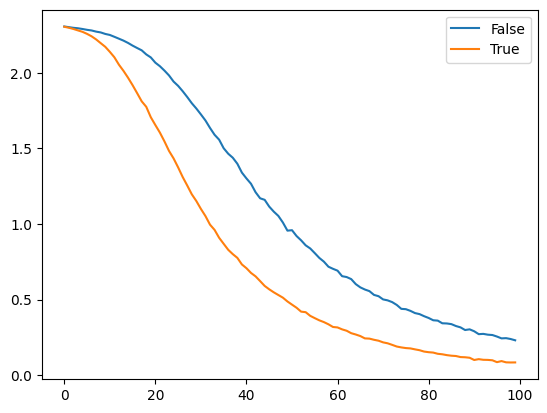

In [ ]:
# Loss curves - not the interesting plot, since the two runs see different data.
plt.plot(losses, label = "False")
plt.plot(lossesTrue, label = "True")
plt.legend();

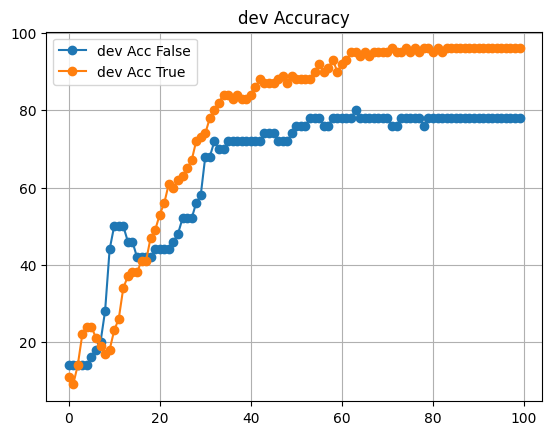

In [ ]:
# DEV accuracy. The augmented run should be ahead: it learned features robust
# to perturbation instead of memorising 250 specific images.
test_acc = [i.cpu() for i in dev_acc]
test_accTrue = [i.cpu() for i in dev_accTrue]

plt.plot(test_acc,'o-',label="dev Acc False")
plt.plot(test_accTrue,'-o',label="dev Acc True")

plt.title("dev Accuracy")
plt.grid()
plt.legend();

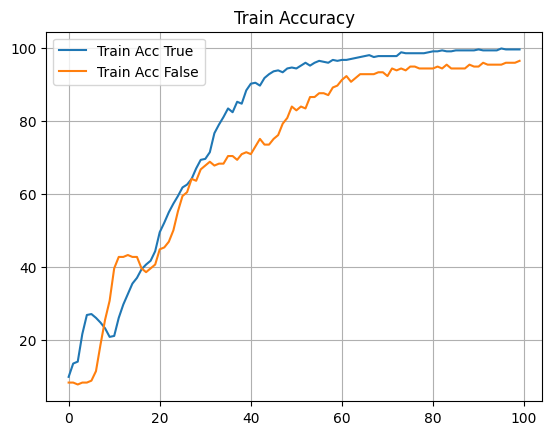

In [ ]:
# TRAIN accuracy. Usually LOWER for the augmented run - noisy samples are
# harder to fit. Lower train accuracy with higher dev accuracy is exactly what
# successful regularisation looks like.
plt.plot(train_accTrue, label="Train Acc True")
plt.plot(train_acc, label="Train Acc False")
plt.grid()
plt.title("Train Accuracy")
plt.legend();

In [ ]:
# The real test set: 10000 MNIST digits, never seen and never augmented.
# Note it is not scaled the way the training data was, so the two are on
# different numeric scales - a distribution mismatch that costs some accuracy.
# Now we test the test set:

test = test_data.data.view(-1,784).to('cuda').float()
label = test_data.targets

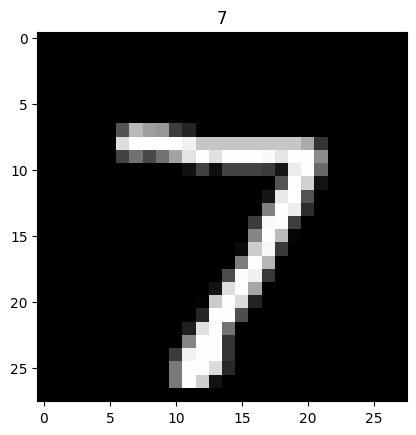

In [ ]:
# One test digit, for a sanity check.
plt.imshow(test[0].detach().cpu().reshape(28,28), cmap='gray')
plt.title(label[0].item());

In [ ]:
# Both models scored on the same untouched test set.
preds_false = torch.argmax(classifier(test), dim = 1)
test_acc_false = 100 * torch.mean( (preds_false.cpu() == label).float())

preds_true = torch.argmax(classifierTrue(test), dim = 1)
test_acc_true = 100 * torch.mean( (preds_true.cpu() == label).float())

In [ ]:
# Train / dev / test for both conditions side by side.
# Read across the row: train >> dev means overfitting; dev >> test means the
# dev split was not representative (here, because of the scaling mismatch).
print(f'Augmentation False : Test Acc {test_acc_false} | Dev Acc : {dev_acc[-1].item()} | Train Acc {train_acc[-1].item()}')
print()
print(f'Augmentation True : Test Acc {test_acc_true} | Dev Acc : {dev_accTrue[-1].item()} | Train Acc {train_accTrue[-1].item()}')

Augmentation False : Test Acc 71.51000213623047 | Dev Acc : 78.0 | Train Acc 96.35416412353516

Augmentation True : Test Acc 76.16999816894531 | Dev Acc : 96.0 | Train Acc 99.47916412353516


# So, when we have less data we can use this for Images